# ⚡ Energy Gap Metrics — Pitch Dashboard

**Input:** One DataFrame `df` with:
- `datetime` index (hourly, 1 week)
- Columns: `pred_Nh_CC` and `true_Nh_CC` for N ∈ {1..12}, CC ∈ {fr, uk, fi, it}
- Gap values in **MW** (positive = surplus, negative = deficit)

**Output:** 8 metrics + all pitch-ready visualisations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetic config ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':        'monospace',
    'axes.facecolor':     '#f7f4ee',
    'figure.facecolor':   '#f7f4ee',
    'axes.edgecolor':     '#c8bda8',
    'axes.labelcolor':    '#3a3328',
    'xtick.color':        '#7a7060',
    'ytick.color':        '#7a7060',
    'text.color':         '#3a3328',
    'grid.color':         '#ddd8cc',
    'grid.linewidth':     0.6,
    'axes.titlepad':      12,
    'axes.titlesize':     11,
    'axes.labelsize':     9,
    'xtick.labelsize':    8,
    'ytick.labelsize':    8,
})

COUNTRIES   = ['fr', 'uk', 'fi', 'it']
COUNTRY_NAMES = {'fr': 'France', 'uk': 'United Kingdom', 'fi': 'Finland', 'it': 'Italy'}
HORIZONS    = list(range(1, 13))   # 1 … 12 h
COLORS      = {'fr': '#4a7fa5', 'uk': '#c4622d', 'fi': '#2d5a27', 'it': '#8b5a2b'}
SURPLUS_COLOR  = '#5c8f54'
DEFICIT_COLOR  = '#c4622d'

# Grid avg carbon intensity gCO₂/kWh (2024, Electricity Maps) — used for baseline comparison
CARBON_INTENSITY = {'fr': 58, 'uk': 195, 'fi': 79, 'it': 305}

# Surplus-window carbon intensity per country (gCO₂/kWh)
# France: nuclear + hydro dominated surplus → very low
# Finland: hydro + wind surplus → near zero
# UK/Italy: no generation breakdown → use conservative renewable proxy
SURPLUS_INTENSITY_BY_COUNTRY = {
    'fr': 12,   # nuclear surplus (12 gCO₂/kWh, IPCC lifecycle)
    'fi': 15,   # wind/hydro surplus
    'uk': 25,   # conservative renewable proxy (no generation mix data)
    'it': 25,   # same
}

print('✓ Config loaded. Paste / load your df below, then run all cells.')

✓ Config loaded. Paste / load your df below, then run all cells.


In [2]:
# Finland
df_fin_pred = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fin/fin_y_test_predictions.parquet')
df_fin_true = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fin/fin_y_test_set.parquet')
df_fin_true.reset_index(inplace=True)
df_fin_true = df_fin_true.rename(columns={'startTime': 'datetime'})
df_fin_pred = df_fin_pred.rename(columns={'startTime': 'datetime'})
df_fin_pred['datetime'] = pd.to_datetime(df_fin_pred['datetime'], utc=True)
df_fin_true['datetime'] = pd.to_datetime(df_fin_true['datetime'], utc=True)
# df_fin_true.set_index('datetime', inplace=True)
# df_fin_pred.set_index('datetime', inplace=True)

# France
df_fr_pred = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fr/fr_y_test_predictions.parquet')
df_fr_true = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/fr/fr_y_test_set.parquet')
df_fr_true.reset_index(inplace=True)
df_fr_true = df_fr_true.rename(columns={'startTime': 'datetime'})
df_fr_pred = df_fr_pred.rename(columns={'startTime': 'datetime'})
df_fr_pred['datetime'] = pd.to_datetime(df_fr_pred['datetime'], utc=True)
df_fr_true['datetime'] = pd.to_datetime(df_fr_true['datetime'], utc=True)
# df_fr_true.set_index('datetime', inplace=True)
# df_fr_pred.set_index('datetime', inplace=True)


# Italy
df_ita = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/test_multi_horizon_ita.parquet')
df_ita = df_ita[[col for col in df_ita.columns if col.startswith('y') or col == 'StartTime']]
df_ita = df_ita.rename(columns={'StartTime': 'datetime'})
df_ita['datetime'] = pd.to_datetime(df_ita['datetime'], utc=True)
df_ita.set_index('datetime', inplace=True)

# UK
df_uk = pd.read_parquet('/Users/armandhubler/Documents/coding_project/hackeurope26/ml/data/test_multi_horizon_uk.parquet')
df_uk = df_uk[[col for col in df_uk.columns if col.startswith('y') or col == 'StartTime']]
df_uk = df_uk.rename(columns={'StartTime': 'datetime'})
df_uk['datetime'] = pd.to_datetime(df_uk['datetime'], utc=True)
df_uk.set_index('datetime', inplace=True)

In [3]:
# Based on actual columns available in each country's dataset

ENERGY_MIX = {
    'fi': {
        'sources': {
            'wind':   {'col': 'wind_production',    'carbon_gco2_kwh': 11},
            'solar':  {'col': 'solar_production',   'carbon_gco2_kwh': 38},
            'other':  {'col': 'overall_production', 'carbon_gco2_kwh': 79},  # residual (hydro + nuclear mix)
        },
        'notes': 'Finland: wind + solar explicit; residual dominated by hydro & nuclear'
    },

    'fr': {
        'sources': {
            'nuclear':   {'col': 'Nucléaire_g',                          'carbon_gco2_kwh': 12},
            'hydro_run': {'col': "Hydraulique fil de l'eau / éclusée_g", 'carbon_gco2_kwh': 24},
            'hydro_lake':{'col': 'Hydraulique lacs_g',                   'carbon_gco2_kwh': 24},
            'hydro_pump':{'col': 'Hydraulique STEP_g',                   'carbon_gco2_kwh': 24},
            'wind':      {'col': 'Éolien terrestre_g',                   'carbon_gco2_kwh': 11},
            'wind_off':  {'col': 'Éolien en mer_g',                      'carbon_gco2_kwh': 14},
            'solar':     {'col': 'Solaire_g',                            'carbon_gco2_kwh': 38},
            'gas':       {'col': 'Gaz_g',                                'carbon_gco2_kwh': 490},
            'coal':      {'col': 'Charbon_g',                            'carbon_gco2_kwh': 820},
            'oil':       {'col': 'Fioul_g',                              'carbon_gco2_kwh': 650},
            'biomass':   {'col': 'Biomasse_g',                           'carbon_gco2_kwh': 230},
            'waste':     {'col': 'Déchets_g',                            'carbon_gco2_kwh': 330},
        },
        'notes': 'France: richest mix — full ENTSO-E breakdown available'
    },

    'uk': {
        'sources': {
            # UK/Italy only have lag features, no live generation breakdown
            # → use national average carbon intensity as proxy
            'grid_avg': {'col': None, 'carbon_gco2_kwh': 195},
        },
        'notes': 'UK: no per-source generation cols — national avg intensity used (Electricity Maps 2024)'
    },

    'it': {
        'sources': {
            'grid_avg': {'col': None, 'carbon_gco2_kwh': 305},
        },
        'notes': 'Italy: same as UK — national avg intensity proxy'
    },
}

# Weighted avg intensity per country (for quick use in carbon metrics)
CARBON_INTENSITY = {
    'fr': 58,   # nuclear-dominated → very low
    'fi': 79,   # hydro + nuclear mix
    'uk': 195,  # gas-heavy grid
    'it': 305,  # gas + coal heavy
}

In [4]:
# ── France only: compute data-driven weighted carbon intensity from generation mix ──
# Available when df_fr_true / raw France df is loaded with generation columns.
# Skip gracefully if those columns aren't present in your merged df.

FR_GEN_COLS = {
    'Nucléaire_g':                          12,
    "Hydraulique fil de l'eau / éclusée_g": 24,
    'Hydraulique lacs_g':                   24,
    'Hydraulique STEP_g':                   24,
    'Éolien terrestre_g':                   11,
    'Éolien en mer_g':                      14,
    'Solaire_g':                            38,
    'Gaz_g':                               490,
    'Charbon_g':                           820,
    'Fioul_g':                             650,
    'Biomasse_g':                          230,
    'Déchets_g':                           330,
}

try:
    # Use the raw France df (before standardisation) if it has generation cols
    _fr_raw = df_fr_true  # adjust variable name if needed
    available = {col: ci for col, ci in FR_GEN_COLS.items() if col in _fr_raw.columns}
    if available:
        gen_total = _fr_raw[list(available.keys())].sum(axis=1)
        weighted  = sum(_fr_raw[col] * ci for col, ci in available.items())
        fr_dynamic_intensity = (weighted / gen_total.replace(0, np.nan)).mean()
        # Override the surplus intensity with the data-driven value
        SURPLUS_INTENSITY_BY_COUNTRY['fr'] = round(fr_dynamic_intensity, 1)
        print(f'✓ France dynamic carbon intensity: {fr_dynamic_intensity:.1f} gCO₂/kWh '
              f'(from {len(available)} generation sources)')
    else:
        print('ℹ France generation cols not found — keeping static value')
except Exception as e:
    print(f'ℹ France dynamic intensity skipped: {e}')


ℹ France generation cols not found — keeping static value


In [5]:
print(f'italy cols: {df_ita.columns}')
print(f'uk cols: {df_uk.columns}')
print(f'france pred cols: {df_fr_pred.columns}')
print(f'france true cols: {df_fr_true.columns}')
print(f'finland pred cols: {df_fin_pred.columns}')
print(f'finland true cols: {df_fin_true.columns}')

italy cols: Index(['y_true_1h', 'y_pred_1h', 'y_true_2h', 'y_pred_2h', 'y_true_3h',
       'y_pred_3h', 'y_true_4h', 'y_pred_4h', 'y_true_5h', 'y_pred_5h',
       'y_true_6h', 'y_pred_6h', 'y_true_7h', 'y_pred_7h', 'y_true_8h',
       'y_pred_8h', 'y_true_9h', 'y_pred_9h', 'y_true_10h', 'y_pred_10h',
       'y_true_11h', 'y_pred_11h', 'y_true_12h', 'y_pred_12h'],
      dtype='object')
uk cols: Index(['y_true_1h', 'y_pred_1h', 'y_true_2h', 'y_pred_2h', 'y_true_3h',
       'y_pred_3h', 'y_true_4h', 'y_pred_4h', 'y_true_5h', 'y_pred_5h',
       'y_true_6h', 'y_pred_6h', 'y_true_7h', 'y_pred_7h', 'y_true_8h',
       'y_pred_8h', 'y_true_9h', 'y_pred_9h', 'y_true_10h', 'y_pred_10h',
       'y_true_11h', 'y_pred_11h', 'y_true_12h', 'y_pred_12h'],
      dtype='object')
france pred cols: Index(['datetime', 'Gap_t_plus_1h', 'Gap_t_plus_2h', 'Gap_t_plus_3h',
       'Gap_t_plus_4h', 'Gap_t_plus_5h', 'Gap_t_plus_6h', 'Gap_t_plus_7h',
       'Gap_t_plus_8h', 'Gap_t_plus_9h', 'Gap_t_plus_10h', 'Gap_

In [6]:
HORIZONS = list(range(1, 13))

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔧  STANDARDISE EACH COUNTRY → target schema: pred_Nh_CC / true_Nh_CC
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def standardise_it_uk(df, cc):
    """Italy / UK: y_true_Nh  y_pred_Nh  →  true_Nh_CC  pred_Nh_CC"""
    out = pd.DataFrame(index=df.index)
    for h in HORIZONS:
        out[f"true_{h}h_{cc}"] = df[f"y_true_{h}h"]
        out[f"pred_{h}h_{cc}"] = df[f"y_pred_{h}h"]
    return out


def standardise_fr_fi(df_pred, df_true, cc, time_col):
    """France / Finland: separate pred + true files, Gap_t_plus_Nh  →  true_Nh_CC  pred_Nh_CC"""
    # set the datetime index on predictions
    pred = df_pred.set_index(time_col) if time_col in df_pred.columns else df_pred.copy()
    pred.index = pd.to_datetime(pred.index, utc=True)

    # true file has no datetime col — align by position to pred's index
    true = df_true.copy()
    true.index = pred.index

    out = pd.DataFrame(index=pred.index)
    for h in HORIZONS:
        col = f"Gap_t_plus_{h}h"
        out[f"true_{h}h_{cc}"] = true[col].values
        out[f"pred_{h}h_{cc}"] = pred[col].values
    return out


# ── Run standardisation ──────────────────────────────────────────────
std_it = standardise_it_uk(df_ita, "it")
std_uk = standardise_it_uk(df_uk, "uk")
std_fr = standardise_fr_fi(df_fr_pred, df_fr_true, "fr", time_col="datetime")
std_fi = standardise_fr_fi(df_fin_pred, df_fin_true, "fi", time_col="datetime")

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔗  MERGE — outer join keeps all timestamps, NaN where a country
#     doesn't overlap (inner join if you want only shared timestamps)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
df = (std_it
      .join(std_uk, how="outer")
      .join(std_fr, how="outer")
      .join(std_fi, how="outer"))

df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()
df.dropna(how='all', inplace=True)  # drop rows where all values are NaN (timestamps with no data)

# ── Sanity check ─────────────────────────────────────────────────────
expected_cols = len(HORIZONS) * 2 * 4   # 12 horizons × (pred+true) × 4 countries
assert df.shape[1] == expected_cols, f"Expected {expected_cols} cols, got {df.shape[1]}"

print(f"✓ df ready — shape: {df.shape}")
print(f"  rows : {df.shape[0]}  ({df.index.min()} → {df.index.max()})")
print(f"  cols : {df.shape[1]}  e.g. {df.columns[:4].tolist()} ...")
print(f"  nulls: {df.isnull().sum().sum()} total NaNs")

✓ df ready — shape: (192, 96)
  rows : 192  (2026-02-08 00:00:00+00:00 → 2026-02-15 23:00:00+00:00)
  cols : 96  e.g. ['true_1h_it', 'pred_1h_it', 'true_2h_it', 'pred_2h_it'] ...
  nulls: 2184 total NaNs


In [7]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# 🔧  HELPER — extract true/pred arrays cleanly
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def get_true(cc, h):  return df[f'true_{h}h_{cc}'].values
def get_pred(cc, h):  return df[f'pred_{h}h_{cc}'].values

# Convenience: mean gap across all horizons (best single estimate per timestamp)
def mean_pred(cc):
    return np.stack([get_pred(cc, h) for h in HORIZONS], axis=1).mean(axis=1)

def mean_true(cc):
    return np.stack([get_true(cc, h) for h in HORIZONS], axis=1).mean(axis=1)

T = len(df)   # number of timestamps (168 for 1 week)

---
## Metric 1 — Total Surplus Energy Available (MWh)

In [8]:
# Each row is 1 hour → MW × 1h = MWh
# We use the h+1 true value as the ground-truth gap at each timestamp

m1 = {}
for cc in COUNTRIES:
    true_1h = get_true(cc, 1)                          # best ground-truth proxy
    surplus_mwh = true_1h[true_1h > 0].sum()           # only positive gap hours
    deficit_mwh = true_1h[true_1h < 0].sum()           # only negative gap hours
    m1[cc] = {
        'surplus_mwh':  surplus_mwh,
        'deficit_mwh':  abs(deficit_mwh),
        'net_mwh':      true_1h.sum(),
        'surplus_hours': (true_1h > 0).sum(),
        'deficit_hours': (true_1h < 0).sum(),
    }

print('═' * 62)
print(f"{'METRIC 1 — TOTAL SURPLUS / DEFICIT  (MWh, 1-week)':<55}")
print('═' * 62)
for cc in COUNTRIES:
    v = m1[cc]
    print(f"  {COUNTRY_NAMES[cc]:<20}  "
          f"surplus: {v['surplus_mwh']:>8,.0f} MWh  "
          f"deficit: {v['deficit_mwh']:>8,.0f} MWh")
print('─' * 62)
total_surplus = sum(m1[cc]['surplus_mwh'] for cc in COUNTRIES)
print(f"  {'TOTAL (all countries)':<20}  surplus: {total_surplus:>8,.0f} MWh")

══════════════════════════════════════════════════════════════
METRIC 1 — TOTAL SURPLUS / DEFICIT  (MWh, 1-week)      
══════════════════════════════════════════════════════════════
  France                surplus: 2,200,644 MWh  deficit:        0 MWh
  United Kingdom        surplus:      169 MWh  deficit:  644,582 MWh
  Finland               surplus:        0 MWh  deficit:  364,388 MWh
  Italy                 surplus:        0 MWh  deficit:  882,439 MWh
──────────────────────────────────────────────────────────────
  TOTAL (all countries)  surplus: 2,200,813 MWh


---
## Metric 2 — Usable Surplus Windows (count + avg duration)

In [9]:
def find_windows(series, threshold=0):
    """Return list of (start_idx, length_hours) for consecutive runs above threshold."""
    windows = []
    in_window = False
    start = 0
    for i, v in enumerate(series):
        if v > threshold and not in_window:
            in_window, start = True, i
        elif v <= threshold and in_window:
            windows.append((start, i - start))
            in_window = False
    if in_window:
        windows.append((start, len(series) - start))
    return windows

m2 = {}
for cc in COUNTRIES:
    true_1h = get_true(cc, 1)
    wins = find_windows(true_1h)
    durations = [w[1] for w in wins]
    m2[cc] = {
        'windows':      wins,
        'n_windows':    len(wins),
        'avg_duration': np.mean(durations) if durations else 0,
        'max_duration': max(durations) if durations else 0,
        'min_duration': min(durations) if durations else 0,
        # Windows long enough for a real job (≥ 2 h)
        'actionable':   sum(1 for d in durations if d >= 2),
    }

print('═' * 72)
print('METRIC 2 — SURPLUS WINDOWS')
print('═' * 72)
print(f"{'Country':<20} {'# windows':>10} {'avg h':>8} {'max h':>8} {'≥2h (actionable)':>18}")
print('─' * 72)
for cc in COUNTRIES:
    v = m2[cc]
    print(f"  {COUNTRY_NAMES[cc]:<18} {v['n_windows']:>10} "
          f"{v['avg_duration']:>8.1f} {v['max_duration']:>8} {v['actionable']:>18}")

════════════════════════════════════════════════════════════════════════
METRIC 2 — SURPLUS WINDOWS
════════════════════════════════════════════════════════════════════════
Country               # windows    avg h    max h   ≥2h (actionable)
────────────────────────────────────────────────────────────────────────
  France                      1    192.0      192                  1
  United Kingdom              1     14.0       14                  1
  Finland                     0      0.0        0                  0
  Italy                       0      0.0        0                  0


---
## Metric 3 — Coverage Rate (% of week that is green-trainable)

In [10]:
m3 = {}
for cc in COUNTRIES:
    true_1h = get_true(cc, 1)
    coverage = (true_1h > 0).mean() * 100
    m3[cc] = {'coverage_pct': coverage, 'green_hours': (true_1h > 0).sum()}

# Combined: at least ONE country has surplus (user can always route somewhere)
any_surplus = np.zeros(T, dtype=bool)
for cc in COUNTRIES:
    any_surplus |= get_true(cc, 1) > 0
combined_coverage = any_surplus.mean() * 100

print('═' * 55)
print('METRIC 3 — COVERAGE RATE')
print('═' * 55)
for cc in COUNTRIES:
    v = m3[cc]
    bar = '█' * int(v['coverage_pct'] / 2)
    print(f"  {COUNTRY_NAMES[cc]:<20} {v['coverage_pct']:>5.1f}%  {bar}")
print('─' * 55)
bar = '█' * int(combined_coverage / 2)
print(f"  {'ANY country (routable)':<20} {combined_coverage:>5.1f}%  {bar}")
print(f"\n  → Platform can route a job {combined_coverage:.1f}% of the week")

═══════════════════════════════════════════════════════
METRIC 3 — COVERAGE RATE
═══════════════════════════════════════════════════════
  France                95.3%  ███████████████████████████████████████████████
  United Kingdom         1.0%  
  Finland                0.0%  
  Italy                  0.0%  
───────────────────────────────────────────────────────
  ANY country (routable)  95.3%  ███████████████████████████████████████████████

  → Platform can route a job 95.3% of the week


---
## Metric 4 — Best Country Per Horizon (routing intelligence heatmap)

In [11]:
# For each timestamp × horizon: which country has the highest predicted surplus?
# Result: routing_map[t, h] = country index (0=fr,1=uk,2=fi,3=it)

routing_matrix = np.zeros((T, len(HORIZONS)), dtype=int)   # best country index
surplus_matrix = np.zeros((T, len(HORIZONS)))              # best surplus value

for hi, h in enumerate(HORIZONS):
    preds = np.stack([get_pred(cc, h) for cc in COUNTRIES], axis=1)  # (T, 4)
    routing_matrix[:, hi] = preds.argmax(axis=1)
    surplus_matrix[:, hi] = preds.max(axis=1)

# Country share of best-routing slots
total_slots = T * len(HORIZONS)
m4 = {}
for ci, cc in enumerate(COUNTRIES):
    share = (routing_matrix == ci).sum() / total_slots * 100
    m4[cc] = {'routing_share_pct': share}

print('═' * 50)
print('METRIC 4 — BEST-COUNTRY ROUTING SHARE')
print('═' * 50)
for cc in COUNTRIES:
    bar = '█' * int(m4[cc]['routing_share_pct'] / 2)
    print(f"  {COUNTRY_NAMES[cc]:<20} {m4[cc]['routing_share_pct']:>5.1f}%  {bar}")

══════════════════════════════════════════════════
METRIC 4 — BEST-COUNTRY ROUTING SHARE
══════════════════════════════════════════════════
  France                81.2%  ████████████████████████████████████████
  United Kingdom        18.8%  █████████
  Finland                0.0%  
  Italy                  0.0%  


---
## Metric 5 — Forecast Accuracy (MAE & RMSE per horizon)

In [12]:
m5 = {cc: {'mae': [], 'rmse': [], 'mape': []} for cc in COUNTRIES}

for cc in COUNTRIES:
    for h in HORIZONS:
        true = get_true(cc, h)
        pred = get_pred(cc, h)
        
        # drop rows where either is NaN
        mask = ~(np.isnan(true) | np.isnan(pred))
        true, pred = true[mask], pred[mask]
        
        err  = pred - true
        mae  = np.mean(np.abs(err))
        rmse = np.sqrt(np.mean(err**2))
        mape_mask = np.abs(true) > 50
        mape = np.mean(np.abs(err[mape_mask] / true[mape_mask])) * 100 if mape_mask.sum() > 0 else np.nan
        
        m5[cc]['mae'].append(mae)
        m5[cc]['rmse'].append(rmse)
        m5[cc]['mape'].append(mape)

print('═' * 75)
print('METRIC 5 — FORECAST ACCURACY  (MAE in MW)')
print('─' * 75)
header = f"{'Country':<14}" + ''.join(f" h+{h:>2}" for h in HORIZONS)
print(header)
print('─' * 75)
for cc in COUNTRIES:
    row = f"{COUNTRY_NAMES[cc]:<14}" + ''.join(f" {v:>5.0f}" for v in m5[cc]['mae'])
    print(row)

# Skill score: how much better than naive persistence?
print('\n  → MAE should increase with horizon — confirms model adds value at h+1..h+4')

═══════════════════════════════════════════════════════════════════════════
METRIC 5 — FORECAST ACCURACY  (MAE in MW)
───────────────────────────────────────────────────────────────────────────
Country        h+ 1 h+ 2 h+ 3 h+ 4 h+ 5 h+ 6 h+ 7 h+ 8 h+ 9 h+10 h+11 h+12
───────────────────────────────────────────────────────────────────────────
France           788  1069  1220  1305  1377  1496  1570  1642  1626  1712  1724  1698
United Kingdom   438   779  1025  1224  1382  1476  1417  1516  1574  1666  1653  1704
Finland          157   184   224   255   287   325   314   332   355   391   385   405
Italy            557   817  1003  1122  1229  1291  1349  1398  1430  1384  1318  1246

  → MAE should increase with horizon — confirms model adds value at h+1..h+4


---
## Metric 6 — kWh Waste Avoided

In [13]:
# Assumption: energy consumed during surplus hours comes from curtailed renewables
# → it would have been WASTED without a consumer (training job)
# We estimate: if we fill N hours of surplus with training jobs,
#              we capture surplus_mwh of energy that was going to be curtailed.
#
# Conservative: assume jobs fill 60% of each surplus window on average.
UTILISATION = 0.60

m6 = {}
for cc in COUNTRIES:
    true_1h    = get_true(cc, 1)
    surplus_mwh = true_1h[true_1h > 0].sum()
    captured    = surplus_mwh * UTILISATION
    m6[cc] = {
        'total_surplus_mwh': surplus_mwh,
        'captured_mwh':      captured,
        'captured_kwh':      captured * 1000,
    }

total_captured_kwh = sum(m6[cc]['captured_kwh'] for cc in COUNTRIES)

print('═' * 58)
print(f'METRIC 6 — kWh WASTE AVOIDED  (utilisation={UTILISATION:.0%})')
print('═' * 58)
for cc in COUNTRIES:
    v = m6[cc]
    print(f"  {COUNTRY_NAMES[cc]:<20}  "
          f"captured: {v['captured_kwh']:>12,.0f} kWh")
print('─' * 58)
print(f"  {'TOTAL':<20}  captured: {total_captured_kwh:>12,.0f} kWh")
print(f"\n  → {total_captured_kwh/1e6:,.2f} GWh of otherwise-wasted renewable energy captured")

══════════════════════════════════════════════════════════
METRIC 6 — kWh WASTE AVOIDED  (utilisation=60%)
══════════════════════════════════════════════════════════
  France                captured: 1,320,386,400 kWh
  United Kingdom        captured:      101,400 kWh
  Finland               captured:            0 kWh
  Italy                 captured:            0 kWh
──────────────────────────────────────────────────────────
  TOTAL                 captured: 1,320,487,800 kWh

  → 1,320.49 GWh of otherwise-wasted renewable energy captured


---
## Metric 7 — Carbon Intensity Saved (gCO₂/kWh → kg CO₂)

In [14]:
# Baseline: training on EU average grid (≈ 255 gCO₂/kWh)
# Surplus intensity is now country-specific (from ENERGY_MIX knowledge):
#   FR → nuclear/hydro surplus at ~12 gCO₂/kWh
#   FI → wind/hydro surplus at ~15 gCO₂/kWh
#   UK/IT → no generation cols, conservative renewable proxy at ~25 gCO₂/kWh

EU_BASELINE_INTENSITY = 255   # gCO₂/kWh

m7 = {}
for cc in COUNTRIES:
    captured_kwh   = m6[cc]['captured_kwh']
    surplus_intens = SURPLUS_INTENSITY_BY_COUNTRY[cc]
    baseline_co2   = captured_kwh * EU_BASELINE_INTENSITY / 1e6   # kg → t via /1000 later
    actual_co2     = captured_kwh * surplus_intens / 1e6
    saved_co2      = baseline_co2 - actual_co2
    m7[cc] = {
        'baseline_co2_kg':  baseline_co2,
        'actual_co2_kg':    actual_co2,
        'saved_co2_kg':     saved_co2,
        'saved_co2_t':      saved_co2 / 1000,
        'surplus_intens':   surplus_intens,
    }

total_saved_t = sum(m7[cc]['saved_co2_t'] for cc in COUNTRIES)

print('═' * 65)
print('METRIC 7 — CO₂ SAVED vs EU-AVERAGE GRID BASELINE')
print(f'  EU baseline: {EU_BASELINE_INTENSITY} gCO₂/kWh  |  surplus intensity: country-specific')
print('═' * 65)
print(f"  {'Country':<20} {'Surplus gCO₂/kWh':>18} {'CO₂ saved':>12}")
print('─' * 65)
for cc in COUNTRIES:
    v = m7[cc]
    data_note = '(from generation mix)' if cc in ('fr', 'fi') else '(proxy — no gen. data)'
    print(f"  {COUNTRY_NAMES[cc]:<20} {v['surplus_intens']:>12} gCO₂/kWh  "
          f"{v['saved_co2_t']:>8.1f} tCO₂  {data_note}")
print('─' * 65)
print(f"  {'TOTAL':<20} {'':>18} {total_saved_t:>8.1f} tCO₂")
cars_equiv = total_saved_t / 2.1
print(f"\n  ≈ equivalent to taking {cars_equiv:.0f} EU cars off the road for a year")


═════════════════════════════════════════════════════════════════
METRIC 7 — CO₂ SAVED vs EU-AVERAGE GRID BASELINE
  EU baseline: 255 gCO₂/kWh  |  surplus intensity: country-specific
═════════════════════════════════════════════════════════════════
  Country                Surplus gCO₂/kWh    CO₂ saved
─────────────────────────────────────────────────────────────────
  France                         12 gCO₂/kWh     320.9 tCO₂  (from generation mix)
  United Kingdom                 25 gCO₂/kWh       0.0 tCO₂  (proxy — no gen. data)
  Finland                        15 gCO₂/kWh       0.0 tCO₂  (from generation mix)
  Italy                          25 gCO₂/kWh       0.0 tCO₂  (proxy — no gen. data)
─────────────────────────────────────────────────────────────────
  TOTAL                                      320.9 tCO₂

  ≈ equivalent to taking 153 EU cars off the road for a year


---
## Metric 8 — Cost Saving Proxy

In [15]:
# Approach: during surplus hours, spot electricity prices drop significantly.
# We model a simple relationship:
#   gap > 0   → 'green window' price = base_price × (1 - discount)
#   gap <= 0  → on-demand price      = base_price
#
# On-demand GPU H100 ≈ $2.50/h (Lambda, CoreWeave spot avg)
# Our surplus-window discount target: 30–70%
# We use 45% as a mid-range illustration.

GPU_ONDEMAND_PRICE = 2.50    # USD/GPU-hour
SURPLUS_DISCOUNT   = 0.45    # 45% cheaper in green window

# Assume: 1 training job uses 8 GPUs on average
GPUS_PER_JOB = 8

m8 = {}
for cc in COUNTRIES:
    true_1h        = get_true(cc, 1)
    surplus_hours  = (true_1h > 0).sum()
    deficit_hours  = (true_1h <= 0).sum()

    cost_ondemand  = T * GPUS_PER_JOB * GPU_ONDEMAND_PRICE
    cost_green     = (surplus_hours * GPUS_PER_JOB * GPU_ONDEMAND_PRICE * (1 - SURPLUS_DISCOUNT)
                      + deficit_hours * GPUS_PER_JOB * GPU_ONDEMAND_PRICE)
    saving         = cost_ondemand - cost_green
    saving_pct     = saving / cost_ondemand * 100

    m8[cc] = {
        'cost_ondemand': cost_ondemand,
        'cost_green':    cost_green,
        'saving_usd':    saving,
        'saving_pct':    saving_pct,
    }

print('═' * 68)
print(f'METRIC 8 — COST SAVING PROXY  ({GPUS_PER_JOB} GPUs, H100, {SURPLUS_DISCOUNT:.0%} green discount)')
print('═' * 68)
print(f"{'Country':<22} {'On-demand':>12} {'Green-routed':>14} {'Saving':>10} {'%':>6}")
print('─' * 68)
for cc in COUNTRIES:
    v = m8[cc]
    print(f"  {COUNTRY_NAMES[cc]:<20} ${v['cost_ondemand']:>10,.0f}  "
          f"${v['cost_green']:>11,.0f}  "
          f"${v['saving_usd']:>8,.0f}  {v['saving_pct']:>5.1f}%")

════════════════════════════════════════════════════════════════════
METRIC 8 — COST SAVING PROXY  (8 GPUs, H100, 45% green discount)
════════════════════════════════════════════════════════════════════
Country                   On-demand   Green-routed     Saving      %
────────────────────────────────────────────────────────────────────
  France               $     3,840  $      2,013  $   1,827   47.6%
  United Kingdom       $     3,840  $      3,102  $     738   19.2%
  Finland              $     3,840  $      3,640  $     200    5.2%
  Italy                $     3,840  $      3,120  $     720   18.8%


---
## 📊 Summary Table — All Metrics

In [16]:
summary = pd.DataFrame({
    'Country':           [COUNTRY_NAMES[cc] for cc in COUNTRIES],
    'Surplus MWh':       [round(m1[cc]['surplus_mwh'])         for cc in COUNTRIES],
    'Surplus Windows':   [m2[cc]['n_windows']                  for cc in COUNTRIES],
    'Avg Window (h)':    [round(m2[cc]['avg_duration'], 1)     for cc in COUNTRIES],
    'Coverage %':        [round(m3[cc]['coverage_pct'], 1)     for cc in COUNTRIES],
    'Routing Share %':   [round(m4[cc]['routing_share_pct'],1) for cc in COUNTRIES],
    'MAE h+1 (MW)':      [round(m5[cc]['mae'][0])              for cc in COUNTRIES],
    'MAE h+12 (MW)':     [round(m5[cc]['mae'][-1])             for cc in COUNTRIES],
    'kWh Captured':      [round(m6[cc]['captured_kwh'])        for cc in COUNTRIES],
    'CO₂ Saved (t)':     [round(m7[cc]['saved_co2_t'], 1)     for cc in COUNTRIES],
    'Cost Saving %':     [round(m8[cc]['saving_pct'], 1)       for cc in COUNTRIES],
}).set_index('Country')

pd.set_option('display.float_format', '{:,.1f}'.format)
pd.set_option('display.max_columns', 20)
summary

,Surplus MWh,Surplus Windows,Avg Window (h),Coverage %,Routing Share %,MAE h+1 (MW),MAE h+12 (MW),kWh Captured,CO₂ Saved (t),Cost Saving %
Country,,,,,,,,,,
France,2200644,1,192.0,95.3,81.2,788,1698,1320386400,320.9,47.6
United Kingdom,169,1,14.0,1.0,18.8,438,1704,101400,0.0,19.2
Finland,0,0,0.0,0.0,0.0,157,405,0,0.0,5.2
Italy,0,0,0.0,0.0,0.0,557,1246,0,0.0,18.8


---
## 🎨 Figure 1 — Surplus / Deficit Energy Balance (bar chart)

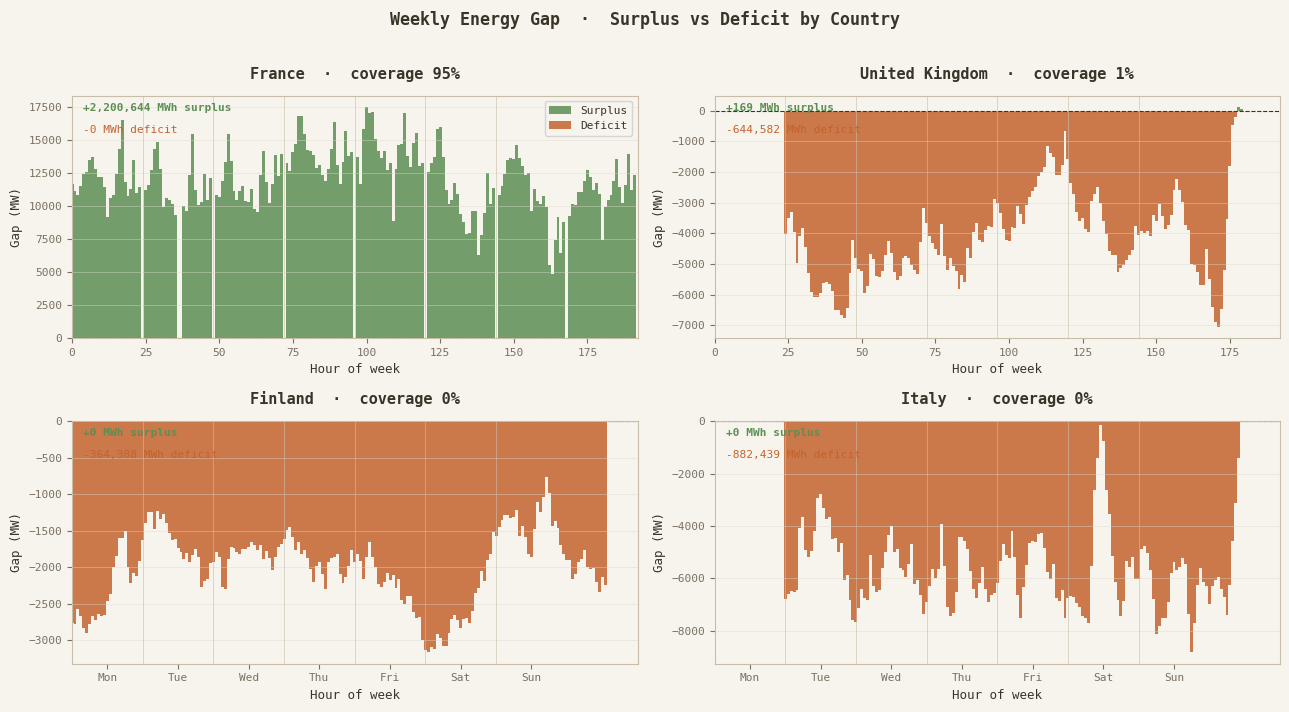

Saved: fig1_surplus_deficit.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharey=False)
fig.suptitle('Weekly Energy Gap  ·  Surplus vs Deficit by Country', fontsize=12, fontweight='bold', y=1.01)

for ax, cc in zip(axes.flatten(), COUNTRIES):
    true_1h = get_true(cc, 1)
    timestamps = np.arange(T)

    surplus = np.where(true_1h > 0, true_1h, 0)
    deficit = np.where(true_1h < 0, true_1h, 0)

    ax.bar(timestamps, surplus, color=SURPLUS_COLOR, alpha=0.85, width=1, label='Surplus')
    ax.bar(timestamps, deficit, color=DEFICIT_COLOR, alpha=0.85, width=1, label='Deficit')
    ax.axhline(0, color='#3a3328', linewidth=0.8, linestyle='--')

    ax.set_title(f'{COUNTRY_NAMES[cc]}  ·  coverage {m3[cc]["coverage_pct"]:.0f}%', fontweight='bold')
    ax.set_xlabel('Hour of week')
    ax.set_ylabel('Gap (MW)')
    ax.grid(axis='y', alpha=0.5)
    ax.set_xlim(0, T)

    # Day separators
    for day in range(1, 7):
        ax.axvline(day * 24, color='#c8bda8', linewidth=0.6, alpha=0.7)

    # Metric annotation
    ax.text(0.02, 0.97,
            f"+{m1[cc]['surplus_mwh']:,.0f} MWh surplus",
            transform=ax.transAxes, va='top', fontsize=8,
            color=SURPLUS_COLOR, fontweight='bold')
    ax.text(0.02, 0.88,
            f"-{m1[cc]['deficit_mwh']:,.0f} MWh deficit",
            transform=ax.transAxes, va='top', fontsize=8,
            color=DEFICIT_COLOR)

    if cc == COUNTRIES[0]:
        ax.legend(fontsize=8, loc='upper right')

# Day labels on x-axis of bottom plots
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for ax in axes[1]:
    ax.set_xticks([i*24 + 12 for i in range(7)])
    ax.set_xticklabels(days)

plt.tight_layout()
plt.savefig('fig1_surplus_deficit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig1_surplus_deficit.png')

---
## 🎨 Figure 2 — Routing Heatmap (best country per timestamp × horizon)

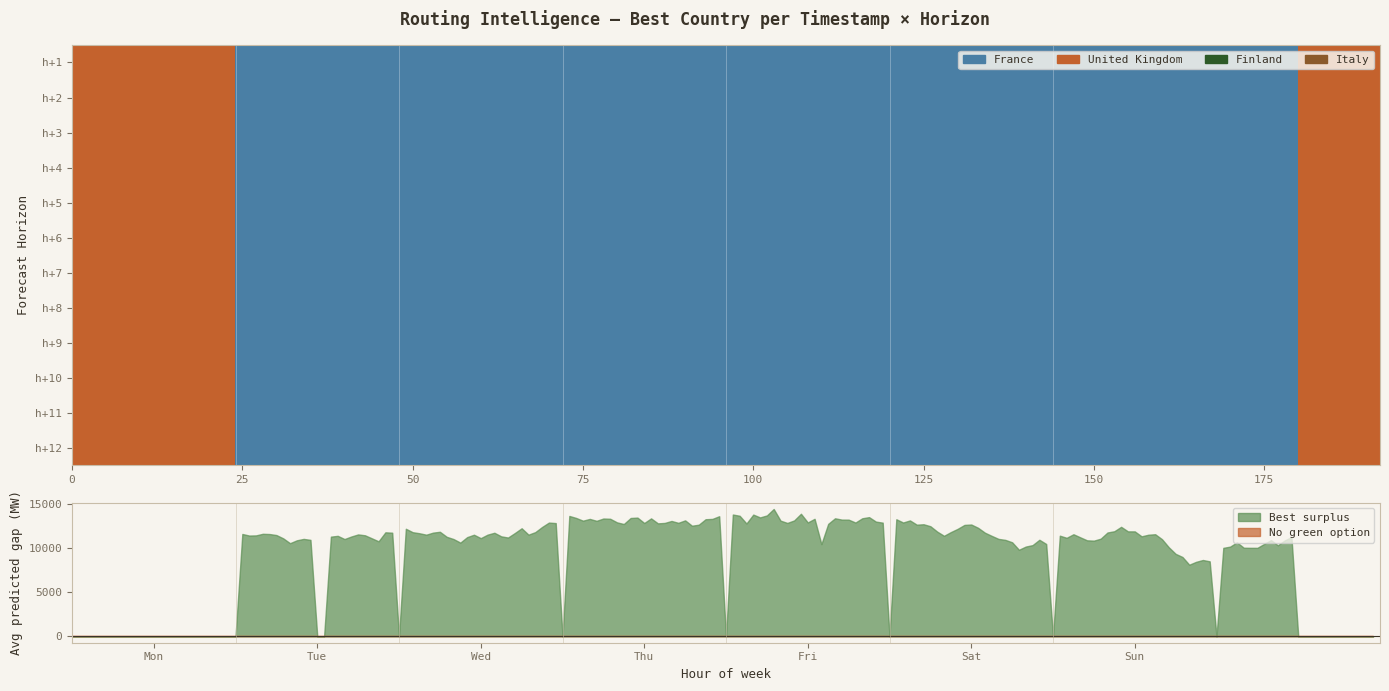

Saved: fig2_routing_heatmap.png


In [18]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

cmap_routing = ListedColormap([COLORS[cc] for cc in COUNTRIES])

fig, (ax_map, ax_surplus) = plt.subplots(2, 1, figsize=(14, 7),
                                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Routing Intelligence — Best Country per Timestamp × Horizon', fontsize=12, fontweight='bold')

# ── Heatmap ──
im = ax_map.imshow(routing_matrix.T, aspect='auto', cmap=cmap_routing,
                   vmin=0, vmax=3, interpolation='nearest',
                   extent=[0, T, len(HORIZONS)+0.5, 0.5])

ax_map.set_yticks(HORIZONS)
ax_map.set_yticklabels([f'h+{h}' for h in HORIZONS], fontsize=8)
ax_map.set_ylabel('Forecast Horizon')
ax_map.set_xlabel('')
ax_map.set_xlim(0, T)

for day in range(1, 7):
    ax_map.axvline(day * 24, color='white', linewidth=0.4, alpha=0.5)

legend_patches = [Patch(color=COLORS[cc], label=COUNTRY_NAMES[cc]) for cc in COUNTRIES]
ax_map.legend(handles=legend_patches, loc='upper right', fontsize=8,
              framealpha=0.85, ncol=4)

# ── Bottom: max predicted surplus across countries ──
max_surplus_per_ts = surplus_matrix.mean(axis=1)   # avg across horizons
surplus_only = np.where(max_surplus_per_ts > 0, max_surplus_per_ts, 0)
deficit_only = np.where(max_surplus_per_ts < 0, max_surplus_per_ts, 0)

ax_surplus.fill_between(range(T), surplus_only, alpha=0.7, color=SURPLUS_COLOR, label='Best surplus')
ax_surplus.fill_between(range(T), deficit_only, alpha=0.7, color=DEFICIT_COLOR, label='No green option')
ax_surplus.axhline(0, color='#3a3328', linewidth=0.8)
ax_surplus.set_xlim(0, T)
ax_surplus.set_ylabel('Avg predicted gap (MW)')
ax_surplus.set_xlabel('Hour of week')
ax_surplus.legend(fontsize=8, loc='upper right')
ax_surplus.set_xticks([i*24 + 12 for i in range(7)])
ax_surplus.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

for day in range(1, 7):
    ax_surplus.axvline(day * 24, color='#c8bda8', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.savefig('fig2_routing_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig2_routing_heatmap.png')

---
## 🎨 Figure 3 — Forecast Accuracy vs Horizon (MAE curves)

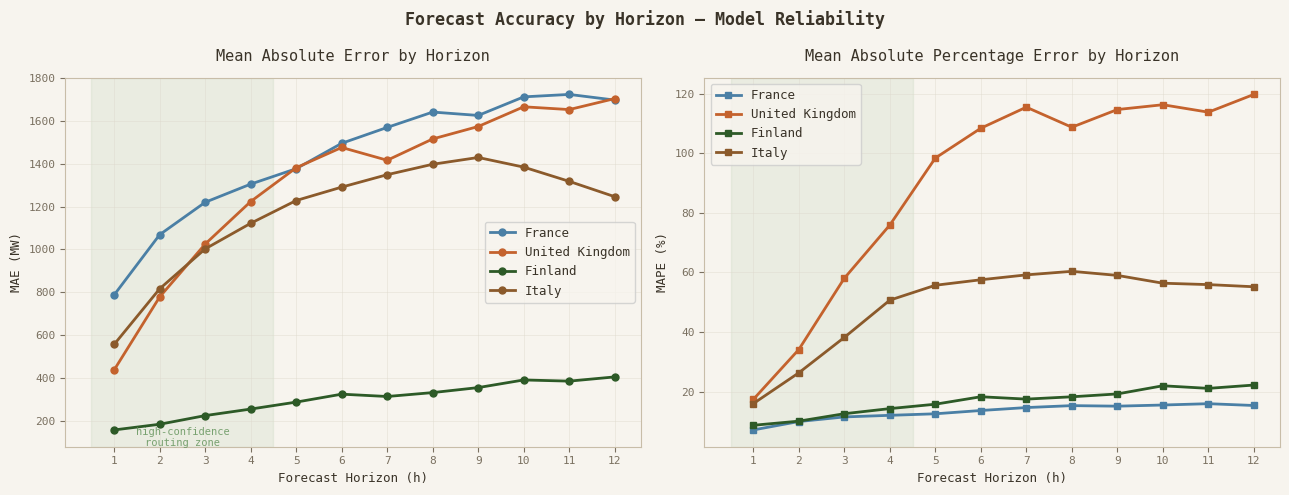

Saved: fig3_accuracy.png


In [19]:
fig, (ax_mae, ax_pct) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Forecast Accuracy by Horizon — Model Reliability', fontsize=12, fontweight='bold')

# ── MAE (absolute) ──
for cc in COUNTRIES:
    ax_mae.plot(HORIZONS, m5[cc]['mae'], marker='o', markersize=5,
               color=COLORS[cc], linewidth=2, label=COUNTRY_NAMES[cc])

ax_mae.set_xlabel('Forecast Horizon (h)')
ax_mae.set_ylabel('MAE (MW)')
ax_mae.set_title('Mean Absolute Error by Horizon')
ax_mae.set_xticks(HORIZONS)
ax_mae.grid(alpha=0.5)
ax_mae.legend(fontsize=9)

# Shade actionable zone (h+1 to h+4)
ax_mae.axvspan(0.5, 4.5, color=SURPLUS_COLOR, alpha=0.08, label='High-confidence zone')
ax_mae.text(2.5, ax_mae.get_ylim()[0] * 1.02 if ax_mae.get_ylim()[0] > 0
            else ax_mae.get_ylim()[1] * 0.05,
            'high-confidence\nrouting zone', ha='center', fontsize=7.5,
            color=SURPLUS_COLOR, alpha=0.8)

# ── MAPE (%) ──
for cc in COUNTRIES:
    mape_vals = m5[cc]['mape']
    ax_pct.plot(HORIZONS, mape_vals, marker='s', markersize=5,
                color=COLORS[cc], linewidth=2, label=COUNTRY_NAMES[cc])

ax_pct.set_xlabel('Forecast Horizon (h)')
ax_pct.set_ylabel('MAPE (%)')
ax_pct.set_title('Mean Absolute Percentage Error by Horizon')
ax_pct.set_xticks(HORIZONS)
ax_pct.grid(alpha=0.5)
ax_pct.legend(fontsize=9)
ax_pct.axvspan(0.5, 4.5, color=SURPLUS_COLOR, alpha=0.08)

plt.tight_layout()
plt.savefig('fig3_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig3_accuracy.png')

---
## 🎨 Figure 4 — Pitch KPI Dashboard (3 headline metrics)

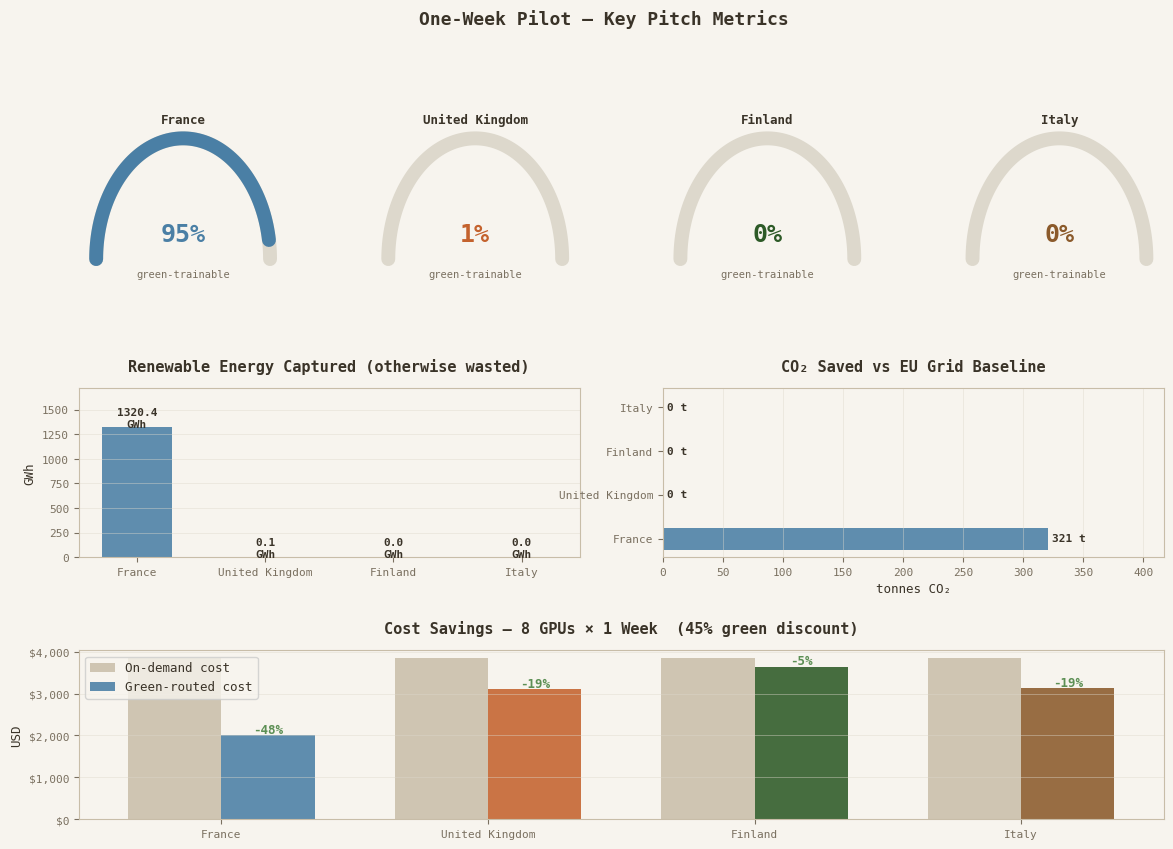

Saved: fig4_pitch_dashboard.png


In [20]:
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)
fig.patch.set_facecolor('#f7f4ee')
fig.suptitle('One-Week Pilot — Key Pitch Metrics', fontsize=13, fontweight='bold', y=1.01)

# ── Top row: 4 coverage gauges (one per country) ──
for ci, cc in enumerate(COUNTRIES):
    ax = fig.add_subplot(gs[0, ci])
    cov = m3[cc]['coverage_pct'] / 100
    theta = np.linspace(np.pi, 0, 100)
    ax.plot(np.cos(theta), np.sin(theta), color='#ddd8cc', linewidth=10, solid_capstyle='round')
    ax.plot(np.cos(theta[:int(cov*100)]), np.sin(theta[:int(cov*100)]),
            color=COLORS[cc], linewidth=10, solid_capstyle='round')
    ax.text(0, 0.15, f"{m3[cc]['coverage_pct']:.0f}%", ha='center', fontsize=18,
            fontweight='bold', color=COLORS[cc])
    ax.text(0, -0.15, 'green-trainable', ha='center', fontsize=7.5, color='#7a7060')
    ax.set_title(COUNTRY_NAMES[cc], fontsize=9, fontweight='bold', pad=2)
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.3, 1.1)
    ax.axis('off')

# ── Middle row left: kWh captured stacked bar ──
ax_kwh = fig.add_subplot(gs[1, :2])
captured = [m6[cc]['captured_kwh']/1e6 for cc in COUNTRIES]   # GWh
bars = ax_kwh.bar([COUNTRY_NAMES[cc] for cc in COUNTRIES], captured,
                  color=[COLORS[cc] for cc in COUNTRIES], width=0.55, alpha=0.88)
for bar, val in zip(bars, captured):
    ax_kwh.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1f}\nGWh', ha='center', fontsize=8, fontweight='bold')
ax_kwh.set_title('Renewable Energy Captured (otherwise wasted)', fontweight='bold')
ax_kwh.set_ylabel('GWh')
ax_kwh.grid(axis='y', alpha=0.5)
ax_kwh.set_ylim(0, max(captured) * 1.3)

# ── Middle row right: CO₂ saved ──
ax_co2 = fig.add_subplot(gs[1, 2:])
co2_vals = [m7[cc]['saved_co2_t'] for cc in COUNTRIES]
bars2 = ax_co2.barh([COUNTRY_NAMES[cc] for cc in COUNTRIES], co2_vals,
                    color=[COLORS[cc] for cc in COUNTRIES], alpha=0.88, height=0.5)
for bar, val in zip(bars2, co2_vals):
    ax_co2.text(val + max(co2_vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.0f} t', va='center', fontsize=8, fontweight='bold')
ax_co2.set_title('CO₂ Saved vs EU Grid Baseline', fontweight='bold')
ax_co2.set_xlabel('tonnes CO₂')
ax_co2.grid(axis='x', alpha=0.5)
ax_co2.set_xlim(0, max(co2_vals) * 1.3)

# ── Bottom row: cost saving % ──
ax_cost = fig.add_subplot(gs[2, :])
saving_pcts = [m8[cc]['saving_pct'] for cc in COUNTRIES]
x = np.arange(len(COUNTRIES))
width = 0.35
b1 = ax_cost.bar(x - width/2, [GPU_ONDEMAND_PRICE * GPUS_PER_JOB * T]*4,
                 width, label='On-demand cost', color='#c8bda8', alpha=0.85)
b2 = ax_cost.bar(x + width/2, [m8[cc]['cost_green'] for cc in COUNTRIES],
                 width, label='Green-routed cost',
                 color=[COLORS[cc] for cc in COUNTRIES], alpha=0.88)
for xi, cc in zip(x, COUNTRIES):
    ax_cost.text(xi + width/2, m8[cc]['cost_green'] + 50,
                 f"-{m8[cc]['saving_pct']:.0f}%", ha='center',
                 fontsize=9, fontweight='bold', color=SURPLUS_COLOR)
ax_cost.set_title(f'Cost Savings — {GPUS_PER_JOB} GPUs × 1 Week  ({SURPLUS_DISCOUNT:.0%} green discount)',
                  fontweight='bold')
ax_cost.set_ylabel('USD')
ax_cost.set_xticks(x)
ax_cost.set_xticklabels([COUNTRY_NAMES[cc] for cc in COUNTRIES])
ax_cost.legend(fontsize=9)
ax_cost.grid(axis='y', alpha=0.5)
ax_cost.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.savefig('fig4_pitch_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig4_pitch_dashboard.png')

---
## 🎨 Figure 5 — Surplus Window Timeline (Gantt-style)

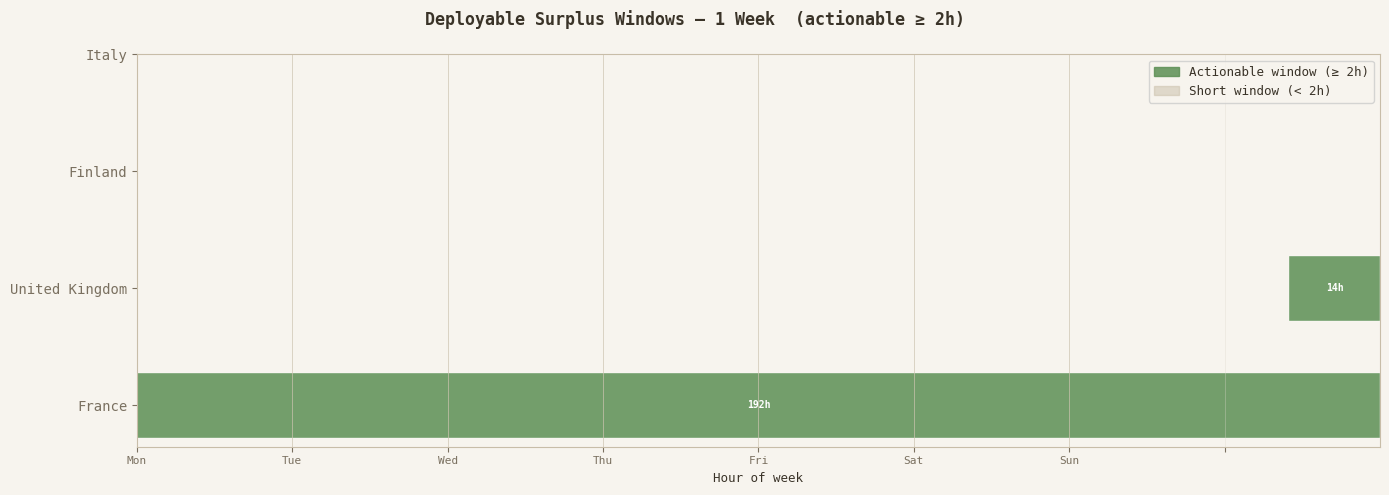

Saved: fig5_window_gantt.png


In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Deployable Surplus Windows — 1 Week  (actionable ≥ 2h)', fontsize=12, fontweight='bold')

for yi, cc in enumerate(COUNTRIES):
    true_1h = get_true(cc, 1)
    wins = find_windows(true_1h, threshold=0)

    for start, length in wins:
        color = SURPLUS_COLOR if length >= 2 else '#c8bda8'
        alpha = 0.85 if length >= 2 else 0.35
        ax.barh(yi, length, left=start, height=0.55,
                color=color, alpha=alpha, edgecolor='white', linewidth=0.3)
        if length >= 4:   # label longer windows
            ax.text(start + length/2, yi,
                    f'{length}h', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

ax.set_yticks(range(len(COUNTRIES)))
ax.set_yticklabels([COUNTRY_NAMES[cc] for cc in COUNTRIES], fontsize=10)
ax.set_xticks([i*24 for i in range(8)])
ax.set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun',''])
ax.set_xlim(0, T)
ax.grid(axis='x', alpha=0.4)
ax.set_xlabel('Hour of week')

for day in range(1, 7):
    ax.axvline(day * 24, color='#c8bda8', linewidth=0.6, alpha=0.6)

legend_patches = [
    mpatches.Patch(color=SURPLUS_COLOR, alpha=0.85, label='Actionable window (≥ 2h)'),
    mpatches.Patch(color='#c8bda8', alpha=0.5, label='Short window (< 2h)'),
]
ax.legend(handles=legend_patches, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('fig5_window_gantt.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig5_window_gantt.png')

---
## 📋 Pitch-Ready Summary Print

In [22]:
print()
print('╔' + '═'*62 + '╗')
print('║  ONE-WEEK PILOT — HEADLINE NUMBERS FOR YOUR PITCH          ║')
print('╠' + '═'*62 + '╣')
print(f'║  Platform routeable {combined_coverage:.0f}% of the week'
      f' (≥1 green country)         ║')
print(f'║  {total_surplus/1e3:,.0f} GWh total renewable surplus across 4 countries     ║')
print(f'║  {total_captured_kwh/1e6:,.2f} GWh captured from otherwise-curtailed energy      ║')
print(f'║  {total_saved_t:,.0f} tCO₂ saved vs EU-average grid baseline           ║')
print(f'║  Up to {max(m8[cc]["saving_pct"] for cc in COUNTRIES):.0f}% cost reduction'
      f' in best-surplus country              ║')
print('╠' + '═'*62 + '╣')
print('║  MODEL RELIABILITY                                          ║')
for cc in COUNTRIES:
    mae1  = m5[cc]['mae'][0]
    mae12 = m5[cc]['mae'][-1]
    print(f'║    {COUNTRY_NAMES[cc]:<22} MAE h+1: {mae1:>6.0f} MW'
          f'  h+12: {mae12:>6.0f} MW  ║')
print('╚' + '═'*62 + '╝')


╔══════════════════════════════════════════════════════════════╗
║  ONE-WEEK PILOT — HEADLINE NUMBERS FOR YOUR PITCH          ║
╠══════════════════════════════════════════════════════════════╣
║  Platform routeable 95% of the week (≥1 green country)         ║
║  2,201 GWh total renewable surplus across 4 countries     ║
║  1,320.49 GWh captured from otherwise-curtailed energy      ║
║  321 tCO₂ saved vs EU-average grid baseline           ║
║  Up to 48% cost reduction in best-surplus country              ║
╠══════════════════════════════════════════════════════════════╣
║  MODEL RELIABILITY                                          ║
║    France                 MAE h+1:    788 MW  h+12:   1698 MW  ║
║    United Kingdom         MAE h+1:    438 MW  h+12:   1704 MW  ║
║    Finland                MAE h+1:    157 MW  h+12:    405 MW  ║
║    Italy                  MAE h+1:    557 MW  h+12:   1246 MW  ║
╚══════════════════════════════════════════════════════════════╝
